N = 241 days, std = 0.0273

False positives at p < 0.05: 5 out of 100
Expected under the null: 5

Top 5 'strongest' false discoveries:
    trial      corr   p_value
66     66  0.168457  0.008785
6       6 -0.165271  0.010168
15     15  0.164196  0.010677
64     64  0.151329  0.018743
31     31  0.145708  0.023677

Bonferroni threshold: p < 0.00050
Survivors after Bonferroni: 0


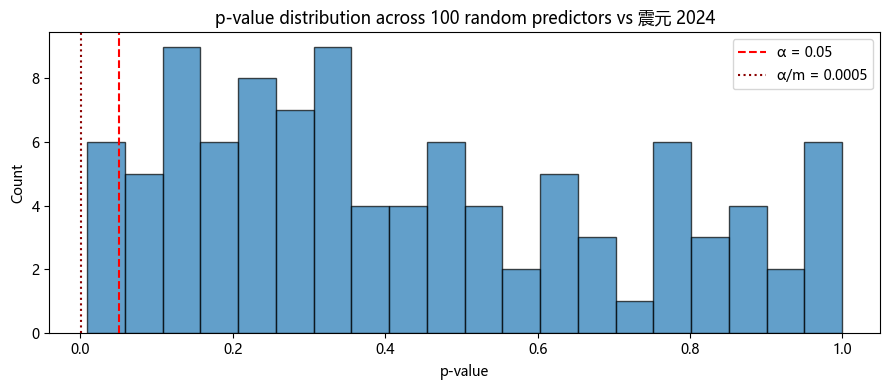

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from utils import load_or_fetch  # your Project 1 helper
from plot_setup import setup_chinese_font
setup_chinese_font()

# Load 震元 2024 returns (you should already have this cached)
# Adjust the path/loader to match your setup
zhenyuan = load_or_fetch('sz.000705', '2024-01-01', '2024-12-31', 'data/prices')
real_returns = zhenyuan['close'].pct_change().dropna().values
N = len(real_returns)
print(f"N = {N} days, std = {real_returns.std():.4f}")

# Run the experiment: 100 random predictors
np.random.seed(42)  # reproducibility
n_tests = 100
results = []

for i in range(n_tests):
    # Generate a random series with similar scale to real returns
    fake_returns = np.random.normal(0, real_returns.std(), N)
    
    # Test correlation between real and fake
    corr, p_value = stats.pearsonr(real_returns, fake_returns)
    results.append({'trial': i, 'corr': corr, 'p_value': p_value})

results_df = pd.DataFrame(results)

# Count false positives at standard threshold
n_significant_005 = (results_df['p_value'] < 0.05).sum()
print(f"\nFalse positives at p < 0.05: {n_significant_005} out of {n_tests}")
print(f"Expected under the null: {n_tests * 0.05:.0f}")

# Show the "best" (most spuriously significant) ones
best = results_df.nsmallest(5, 'p_value')
print("\nTop 5 'strongest' false discoveries:")
print(best)

# Bonferroni threshold
alpha_bonf = 0.05 / n_tests
n_significant_bonf = (results_df['p_value'] < alpha_bonf).sum()
print(f"\nBonferroni threshold: p < {alpha_bonf:.5f}")
print(f"Survivors after Bonferroni: {n_significant_bonf}")

# Visualize the p-value distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(results_df['p_value'], bins=20, edgecolor='black', alpha=0.7)
ax.axvline(0.05, color='red', linestyle='--', label='α = 0.05')
ax.axvline(alpha_bonf, color='darkred', linestyle=':', label=f'α/m = {alpha_bonf:.4f}')
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
ax.set_title('p-value distribution across 100 random predictors vs 震元 2024')
ax.legend()
plt.tight_layout()
plt.show()